In [ ]:
import tensorflow as tf

def encoder_block(inputs, num_filters):
    # Używamy padding='same' żeby zachować wymiary
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    pooled = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x, pooled  # Zwracamy też skip connection przed poolingiem

In [ ]:
def decoder_block(inputs, skip_features, num_filters):
    # Upsampling
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)
    
    # Concatenate ze skip connection
    x = tf.keras.layers.Concatenate()([x, skip_features])
    
    # Konwolucje
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [ ]:
def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1, p1 = encoder_block(inputs, 64)   # 256 -> 128
    s2, p2 = encoder_block(p1, 128)      # 128 -> 64
    s3, p3 = encoder_block(p2, 256)      # 64 -> 32
    s4, p4 = encoder_block(p3, 512)      # 32 -> 16
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(p4)
    b1 = tf.keras.layers.BatchNormalization()(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.BatchNormalization()(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)      # 16 -> 32
    d2 = decoder_block(d1, s3, 256)      # 32 -> 64
    d3 = decoder_block(d2, s2, 128)      # 64 -> 128
    d4 = decoder_block(d3, s1, 64)       # 128 -> 256
    
    # Output - sigmoid dla binarnej segmentacji
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='same', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

# Test modelu
if __name__ == '__main__':
    model = unet_model(input_shape=(256, 256, 3), num_classes=1)
    model.summary()
    print(f"\nInput shape: {model.input_shape}")
    print(f"Output shape: {model.output_shape}")

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_36[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_38[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_42[0][0] 

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)


Input shape: (None, 256, 256, 3)
Output shape: (None, 256, 256, 1)


In [ ]:
# === Konfiguracja ścieżek i generatora ===
import numpy as np
from PIL import Image
import glob
import os
import tensorflow as tf

# Automatyczne wykrywanie ścieżki - działa lokalnie i na Colab
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

# Próbuj różnych ścieżek
possible_paths = [
    os.path.join(NOTEBOOK_DIR, '..', '..', 'data'),  # Lokalna ścieżka relatywna
    r'c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\data',  # Bezwzględna Windows
    '/content/App/data',  # Google Colab
    '/App/data',  # Alternatywna Colab
]

DATA_PATH = None
for path in possible_paths:
    test_path = os.path.join(path, 'processed', 'split', 'train', 'images', 'tiled')
    if os.path.exists(test_path):
        DATA_PATH = path
        print(f" Znaleziono dane w: {DATA_PATH}")
        break

if DATA_PATH is None:
    print(" Nie znaleziono folderu z danymi!")
    print("Sprawdzane ścieżki:")
    for p in possible_paths:
        print(f"  - {p}")
else:
    TRAIN_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/train/images/tiled')
    TRAIN_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/train/masks/tiled')
    VAL_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/val/images/tiled')
    VAL_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/val/masks/tiled')

# Parametry
IMG_SIZE = (256, 256)
BATCH_SIZE = 8

# Sprawdź czy ścieżki istnieją
if DATA_PATH:
    print("\nSprawdzanie ścieżek...")
    for name, path in [("Train IMG", TRAIN_IMG_PATH), ("Train MASK", TRAIN_MASK_PATH),
                       ("Val IMG", VAL_IMG_PATH), ("Val MASK", VAL_MASK_PATH)]:
        if os.path.exists(path):
            folders = os.listdir(path)
            print(f" {name}: {len(folders)} folderów")
        else:
            print(f" {name}: NIE ISTNIEJE - {path}")

def get_tile_pairs(img_base_dir, mask_base_dir):
    """Zbierz ścieżki do par obraz-maska"""
    pairs = []
    
    if not os.path.exists(img_base_dir):
        print(f" Folder nie istnieje: {img_base_dir}")
        return pairs
    
    img_folders = [f for f in os.listdir(img_base_dir) if os.path.isdir(os.path.join(img_base_dir, f))]
    
    for img_folder in img_folders:
        mask_folder = img_folder + "_mask"
        
        img_folder_path = os.path.join(img_base_dir, img_folder)
        mask_folder_path = os.path.join(mask_base_dir, mask_folder)
        
        if not os.path.exists(mask_folder_path):
            continue
        
        tile_files = glob.glob(os.path.join(img_folder_path, '*.png'))
        
        for tile_path in tile_files:
            tile_name = os.path.basename(tile_path)
            mask_path = os.path.join(mask_folder_path, tile_name)
            
            if os.path.exists(mask_path):
                pairs.append((tile_path, mask_path))
    
    return pairs

class TileDataGenerator(tf.keras.utils.Sequence):
    """Generator wczytujący dane partiami - oszczędza RAM"""
    
    def __init__(self, pairs, batch_size=8, img_size=(256, 256), shuffle=True, **kwargs):
        super().__init__(**kwargs)  # Ważne dla Keras 3!
        self.pairs = pairs
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __len__(self):
        return max(1, int(np.ceil(len(self.pairs) / self.batch_size)))
    
    def __getitem__(self, index):
        if len(self.pairs) == 0:
            # Zwróć puste tensory jeśli brak danych
            return np.zeros((1, self.img_size[0], self.img_size[1], 3)), np.zeros((1, self.img_size[0], self.img_size[1], 1))
        
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_pairs = [self.pairs[i] for i in batch_indexes]
        
        images = []
        masks = []
        
        for img_path, mask_path in batch_pairs:
            # Wczytaj i przeskaluj obraz
            img = Image.open(img_path).convert('RGB')
            img = img.resize(self.img_size, Image.Resampling.LANCZOS)
            img = np.array(img) / 255.0
            images.append(img)
            
            # Wczytaj i przeskaluj maskę
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize(self.img_size, Image.Resampling.NEAREST)
            mask = np.array(mask) / 255.0
            mask = mask[..., np.newaxis]
            masks.append(mask)
        
        return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Zbierz pary ścieżek
if DATA_PATH:
    print("\nZbieranie ścieżek do tile'ów...")
    train_pairs = get_tile_pairs(TRAIN_IMG_PATH, TRAIN_MASK_PATH)
    val_pairs = get_tile_pairs(VAL_IMG_PATH, VAL_MASK_PATH)

    print(f" Dane treningowe: {len(train_pairs)} par tile'ów")
    print(f" Dane walidacyjne: {len(val_pairs)} par tile'ów")

    if len(train_pairs) == 0:
        print("\n UWAGA: Brak danych treningowych!")
        print("Sprawdź czy:")
        print("1. Foldery tiled/ istnieją i zawierają pliki .png")
        print("2. Nazwy folderów masek kończą się na _mask")
    else:
        # Utwórz generatory
        train_generator = TileDataGenerator(train_pairs, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True)
        val_generator = TileDataGenerator(val_pairs, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False)
        
        print(f"\nBatchy treningowych: {len(train_generator)}")
        print(f"Batchy walidacyjnych: {len(val_generator)}")
        
        # Test - wczytaj jeden batch
        print("\nTest wczytywania batcha...")
        X_test, y_test = train_generator[0]
        print(f"Batch shape: X={X_test.shape}, y={y_test.shape}")

✅ Znaleziono dane w: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data

Sprawdzanie ścieżek...
✅ Train IMG: 166 folderów
✅ Train MASK: 166 folderów
✅ Val IMG: 51 folderów
✅ Val MASK: 51 folderów

Zbieranie ścieżek do tile'ów...
✅ Dane treningowe: 14608 par tile'ów
✅ Dane walidacyjne: 4488 par tile'ów

Batchy treningowych: 1826
Batchy walidacyjnych: 561

Test wczytywania batcha...
Batch shape: X=(8, 256, 256, 3), y=(8, 256, 256, 1)


In [ ]:
# === Kompilacja i trening modelu ===
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import json

# Ścieżka do zapisywania modeli - automatycznie dla Windows/Colab
MODELS_PATH = os.path.join(DATA_PATH, '..', 'models')
os.makedirs(MODELS_PATH, exist_ok=True)
print(f"📁 Modele będą zapisywane w: {os.path.abspath(MODELS_PATH)}")

# Ścieżki do plików
BEST_MODEL_PATH = os.path.join(MODELS_PATH, 'best_unet.keras')
LAST_MODEL_PATH = os.path.join(MODELS_PATH, 'last_unet.keras')
HISTORY_CSV_PATH = os.path.join(MODELS_PATH, 'training_history.csv')
TRAINING_STATE_PATH = os.path.join(MODELS_PATH, 'training_state.json')

# Sprawdź czy istnieje poprzedni trening do wznowienia
RESUME_TRAINING = False
INITIAL_EPOCH = 0

if os.path.exists(LAST_MODEL_PATH) and os.path.exists(TRAINING_STATE_PATH):
    print("\n🔄 Znaleziono poprzedni trening!")
    with open(TRAINING_STATE_PATH, 'r') as f:
        training_state = json.load(f)
    INITIAL_EPOCH = training_state.get('last_epoch', 0)
    print(f"   Ostatnia ukończona epoka: {INITIAL_EPOCH}")
    
    response = input("   Czy chcesz wznowić trening? (t/n): ").strip().lower()
    if response == 't':
        RESUME_TRAINING = True
        print(f"   ✅ Wznawiam trening od epoki {INITIAL_EPOCH + 1}")
    else:
        INITIAL_EPOCH = 0
        print("   🔄 Rozpoczynam nowy trening od początku")

# Utwórz lub wczytaj model
if RESUME_TRAINING:
    print("\n📂 Wczytywanie modelu z ostatniego checkpointu...")
    model = tf.keras.models.load_model(LAST_MODEL_PATH)
    print("   ✅ Model wczytany!")
else:
    print("\n🏗️ Tworzenie nowego modelu...")
    model = unet_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=1)
    
    # Kompilacja modelu
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.IoU(num_classes=2, target_class_ids=[1], name='iou')]
    )
    print("   ✅ Model skompilowany!")

# Callback do zapisywania stanu treningu
class SaveTrainingState(tf.keras.callbacks.Callback):
    def __init__(self, state_path):
        super().__init__()
        self.state_path = state_path
    
    def on_epoch_end(self, epoch, logs=None):
        state = {
            'last_epoch': epoch + 1,  # +1 bo epoch jest 0-indexed
            'best_val_iou': float(logs.get('val_iou', 0)),
            'last_val_loss': float(logs.get('val_loss', 0)),
            'last_train_loss': float(logs.get('loss', 0))
        }
        with open(self.state_path, 'w') as f:
            json.dump(state, f, indent=2)

# Callbacki
callbacks = [
    # Zapisz NAJLEPSZY model (według val_iou)
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_iou',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Zapisz OSTATNI model (do wznowienia)
    ModelCheckpoint(
        LAST_MODEL_PATH,
        monitor='val_loss',
        save_best_only=False,  # Zapisuj zawsze!
        verbose=0
    ),
    # Zapisz historię do CSV (dopisuje, nie nadpisuje)
    CSVLogger(
        HISTORY_CSV_PATH,
        append=RESUME_TRAINING  # Dopisuj jeśli wznawiamy
    ),
    # Zapisz stan treningu
    SaveTrainingState(TRAINING_STATE_PATH),
    # Zatrzymaj jeśli brak poprawy
    EarlyStopping(
        monitor='val_iou',
        mode='max',
        patience=10,
        verbose=1,
        restore_best_weights=True  # Przywróć najlepsze wagi na koniec
    ),
    # Zmniejsz learning rate gdy plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("\n✅ Gotowy do treningu!")
print(f"   📊 Najlepszy model: {BEST_MODEL_PATH}")
print(f"   💾 Ostatni checkpoint: {LAST_MODEL_PATH}")
print(f"   📈 Historia CSV: {HISTORY_CSV_PATH}")

📁 Modele będą zapisywane w: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\models

🏗️ Tworzenie nowego modelu...
   ✅ Model skompilowany!

✅ Gotowy do treningu!
   📊 Najlepszy model: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\best_unet.keras
   💾 Ostatni checkpoint: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\last_unet.keras
   📈 Historia CSV: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\training_history.csv


In [ ]:
# Sprawdź wartości masek
X, y = train_generator[0]
print(f"Maska - min: {y.min()}, max: {y.max()}, unique: {np.unique(y)}")
print(f"% pikseli klasy 1: {(y > 0.5).mean() * 100:.2f}%")

# Sprawdź predykcje
pred = model.predict(X[:1])
print(f"Pred - min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

Maska - min: 0.0, max: 1.0, unique: [0.         0.00392157 0.00784314 0.01176471 0.01568628 0.01960784
 0.02352941 0.02745098 0.972549   0.9764706  0.98039216 0.9843137
 0.9882353  0.99215686 0.99607843 1.        ]
% pikseli klasy 1: 1.50%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
Pred - min: 0.0000, max: 0.0533, mean: 0.0011


In [ ]:
# === TRENING z generatorem ===
EPOCHS = 50

print(f"\n🚀 Rozpoczynam trening...")
print(f"   Epoki: {INITIAL_EPOCH + 1} → {EPOCHS}")
print(f"   Batchy na epokę: {len(train_generator)}")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    initial_epoch=INITIAL_EPOCH,  # Ważne dla wznowienia!
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Trening zakończony!")

# Zapisz finalny stan
final_state = {
    'last_epoch': EPOCHS,
    'completed': True,
    'best_val_iou': float(max(history.history.get('val_iou', [0]))),
}
with open(TRAINING_STATE_PATH, 'w') as f:
    json.dump(final_state, f, indent=2)
print(f"📊 Najlepsza IoU: {final_state['best_val_iou']:.4f}")


🚀 Rozpoczynam trening...
   Epoki: 1 → 50
   Batchy na epokę: 1826
Epoch 1/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9428 - iou: 0.0000e+00 - loss: 0.1839
Epoch 1: val_iou improved from None to 0.00000, saving model to c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\best_unet.keras
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 7601s 4s/step - accuracy: 0.9532 - iou: 0.0000e+00 - loss: 0.1343 - val_accuracy: 0.9661 - val_iou: 0.0000e+00 - val_loss: 0.0836 - learning_rate: 1.0000e-04
Epoch 2/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9621 - iou: 0.0000e+00 - loss: 0.0925
Epoch 2: val_iou did not improve from 0.00000
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 7411s 4s/step - accuracy: 0.9635 - iou: 0.0000e+00 - loss: 0.0886 - val_accuracy: 0.9522 - val_iou: 0.0000e+00 - val_loss: 0.1193 - learning_rate: 1.0000e-04
Epoch 3/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9667 - iou: 0.0000e+00 - loss: 0.0779
Epoch 3:

KeyboardInterrupt: 

NameError: name 'history' is not defined

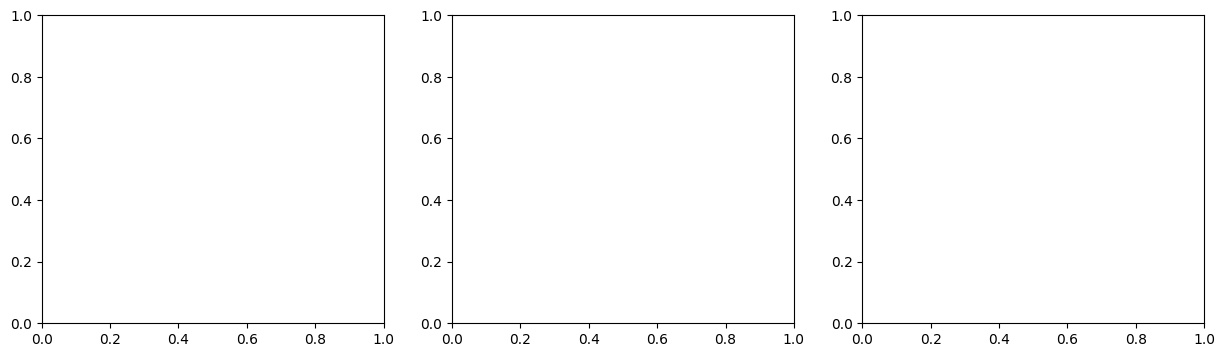

In [ ]:
# === Wizualizacja wyników treningu ===
import matplotlib.pyplot as plt
import pandas as pd

# Wczytaj pełną historię z CSV (zawiera też poprzednie treningi jeśli były)
if os.path.exists(HISTORY_CSV_PATH):
    history_df = pd.read_csv(HISTORY_CSV_PATH)
    print(f"📊 Wczytano historię: {len(history_df)} epok")
else:
    # Użyj historii z obecnego treningu
    history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history_df['loss'], label='Train Loss')
axes[0].plot(history_df['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_df['accuracy'], label='Train Acc')
axes[1].plot(history_df['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(history_df['iou'], label='Train IoU')
axes[2].plot(history_df['val_iou'], label='Val IoU')
axes[2].set_title('IoU (Intersection over Union)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'training_history.png'), dpi=150)
plt.show()

print(f"\n📈 Najlepsza walidacyjna IoU: {history_df['val_iou'].max():.4f} (epoka {history_df['val_iou'].idxmax() + 1})")

In [ ]:
# === Testowanie na zbiorze testowym ===
TEST_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/test/images/tiled')
TEST_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/test/masks/tiled')

print("Zbieranie ścieżek testowych...")
test_pairs = get_tile_pairs(TEST_IMG_PATH, TEST_MASK_PATH)
print(f"✅ Dane testowe: {len(test_pairs)} par tile'ów")

test_generator = TileDataGenerator(test_pairs, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False)

# Wczytaj najlepszy model (format .keras nie wymaga custom_objects)
print(f"\n📂 Wczytywanie najlepszego modelu z: {BEST_MODEL_PATH}")
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Ewaluacja
print("\n🔍 Ewaluacja na zbiorze testowym...")
results = best_model.evaluate(test_generator, verbose=1)
print(f"\n📊 Wyniki na zbiorze testowym:")
print(f"   Loss: {results[0]:.4f}")
print(f"   Accuracy: {results[1]:.4f}")
print(f"   IoU: {results[2]:.4f}")

Zbieranie ścieżek testowych...
✅ Dane testowe: 4928 par tile'ów


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\best_unet.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# === Wizualizacja predykcji ===
import matplotlib.pyplot as plt

# Weź jeden batch do wizualizacji
X_sample, y_sample = test_generator[0]

# Predykcje
predictions = best_model.predict(X_sample)

# Wyświetl przykłady (max 5)
n_examples = min(5, len(X_sample))
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4*n_examples))

for i in range(n_examples):
    # Oryginalny obraz
    axes[i, 0].imshow(X_sample[i])
    axes[i, 0].set_title('Obraz wejściowy')
    axes[i, 0].axis('off')
    
    # Ground truth maska
    axes[i, 1].imshow(y_sample[i].squeeze(), cmap='gray')
    axes[i, 1].set_title('Maska rzeczywista')
    axes[i, 1].axis('off')
    
    # Predykcja
    pred = (predictions[i].squeeze() > 0.5).astype(np.uint8)
    axes[i, 2].imshow(pred, cmap='gray')
    axes[i, 2].set_title('Predykcja modelu')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'predictions_examples.png'), dpi=150)
plt.show()